# Pricing et hedging d'un produit autocallable

**Projet Produits Structurés — M2 BFA**

On développe un pricer Monte Carlo d'un autocall classique sous Black-Scholes, puis on étudie :
1. La sensibilité aux paramètres de marché (volatilité, taux)
2. L'impact d'un modèle de taux stochastique (Vasicek)
3. La performance d'une stratégie de delta-hedging et l'analyse du PnL résiduel

## Imports et configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3
})

## 1. Paramètres du produit et du marché

Autocall à observation annuelle :
- Maturité : 5 ans
- Barrière autocall : 100% du spot initial
- Coupon : 7% par an (cumulé si autocall)
- Protection du capital : barrière à 60% (perte si $S_T < 60\%$)

In [2]:
# -- Marché --
spot_0 = 100.0
vol = 0.20
taux = 0.03

# -- Produit --
maturite = 5
dates_obs = np.arange(1, maturite + 1)
barriere_autocall = 1.0
coupon_annuel = 0.07
barriere_capital = 0.60

# -- Monte Carlo --
nb_simus = 100_000
nb_pas_par_an = 252
np.random.seed(42)

print(f"Spot initial       : {spot_0}")
print(f"Maturité           : {maturite} ans")
print(f"Barrière autocall  : {barriere_autocall*100}%")
print(f"Coupon annuel      : {coupon_annuel*100}%")
print(f"Barrière capital   : {barriere_capital*100}%")
print(f"Volatilité         : {vol*100}%")
print(f"Taux sans risque   : {taux*100}%")

Spot initial       : 100.0
Maturité           : 5 ans
Barrière autocall  : 100.0%
Coupon annuel      : 7.000000000000001%
Barrière capital   : 60.0%
Volatilité         : 20.0%
Taux sans risque   : 3.0%


## 2. Simulation du sous-jacent sous Black-Scholes

Sous risque-neutre :
$$dS_t = r \, S_t \, dt + \sigma \, S_t \, dW_t$$

Discrétisation exacte :
$$S(t+\Delta t) = S(t) \cdot \exp\left[\left(r - \tfrac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t} \, Z\right]$$

In [3]:
def simuler_trajectoires_bs(s0, r, sigma, T, nb_pas, nb_sim):
    """Simule des trajectoires GBM (vectorisé via cumsum)."""
    dt = T / nb_pas
    aleas = np.random.standard_normal((nb_sim, nb_pas))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * aleas
    log_spots = np.concatenate([np.zeros((nb_sim, 1)), np.cumsum(increments, axis=1)], axis=1)
    return s0 * np.exp(log_spots)

nb_pas_total = nb_pas_par_an * maturite
trajectoires = simuler_trajectoires_bs(spot_0, taux, vol, maturite, nb_pas_total, nb_simus)

print(f"Trajectoires : {trajectoires.shape}")
print(f"Spot moyen à maturité : {trajectoires[:, -1].mean():.2f}")

Trajectoires : (100000, 1261)
Spot moyen à maturité : 115.92


## 3. Pricing de l'autocall par Monte Carlo

À chaque date d'observation :
- Si $S_t \geq 100\%$ : autocall, on reçoit nominal + coupons cumulés
- Sinon : on continue

À maturité : capital si $S_T \geq 60\%$, sinon perte proportionnelle.

In [4]:
def pricer_autocall_mc(trajectoires, s0, r, dates_obs, barriere_ac, coupon, barriere_cap, nb_pas_an):
    """Pricing vectorisé de l'autocall."""
    nb_sim = trajectoires.shape[0]
    payoffs = np.zeros(nb_sim)
    dates_autocall = np.full(nb_sim, np.nan)
    vivantes = np.ones(nb_sim, dtype=bool)
    
    for t_obs in dates_obs:
        idx = int(t_obs * nb_pas_an)
        if idx >= trajectoires.shape[1]:
            idx = trajectoires.shape[1] - 1
        spots = trajectoires[vivantes, idx]
        ac_mask = spots >= barriere_ac * s0
        idx_viv = np.where(vivantes)[0]
        idx_ac = idx_viv[ac_mask]
        
        payoffs[idx_ac] = (1.0 + coupon * t_obs) * np.exp(-r * t_obs)
        dates_autocall[idx_ac] = t_obs
        vivantes[idx_ac] = False
    
    if vivantes.any():
        idx_viv = np.where(vivantes)[0]
        s_fin = trajectoires[idx_viv, -1]
        disc = np.exp(-r * dates_obs[-1])
        protege = s_fin >= barriere_cap * s0
        payoffs[idx_viv[protege]] = 1.0 * disc
        payoffs[idx_viv[~protege]] = (s_fin[~protege] / s0) * disc
    
    return payoffs.mean(), payoffs, dates_autocall


prix_autocall, payoffs_ac, dates_ac = pricer_autocall_mc(
    trajectoires, spot_0, taux, dates_obs,
    barriere_autocall, coupon_annuel, barriere_capital, nb_pas_par_an
)

autocalled_mask = ~np.isnan(dates_ac)
proba_autocall = autocalled_mask.mean()

print(f"Prix de l'autocall (MC) : {prix_autocall:.4f} ({prix_autocall*100:.2f}% du nominal)")
print(f"Probabilité d'autocall  : {proba_autocall*100:.1f}%\n")
for t in dates_obs:
    print(f"  Proba autocall t={int(t)} : {(dates_ac == t).mean()*100:.1f}%")
perte = (~autocalled_mask & (trajectoires[:, -1] < barriere_capital * spot_0)).mean()
print(f"\nProba de perte en capital : {perte*100:.1f}%")

Prix de l'autocall (MC) : 0.9807 (98.07% du nominal)
Probabilité d'autocall  : 77.9%

  Proba autocall t=1 : 51.7%
  Proba autocall t=2 : 13.0%
  Proba autocall t=3 : 6.3%
  Proba autocall t=4 : 4.0%
  Proba autocall t=5 : 2.8%

Proba de perte en capital : 7.8%


## 4. Distribution du payoff et trajectoires

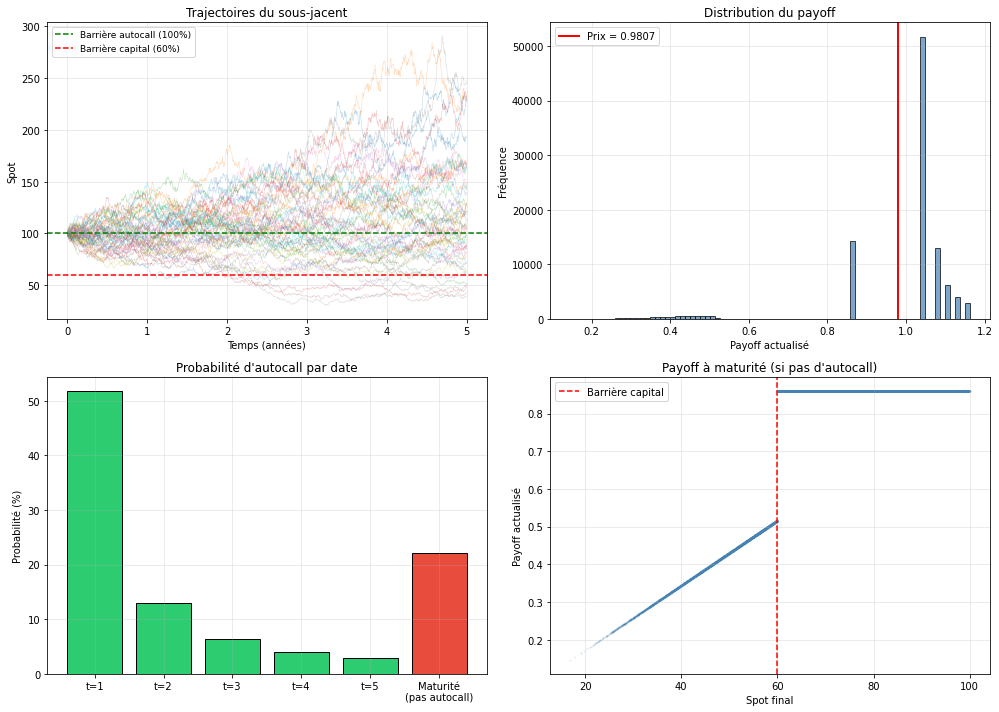

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
t_grid = np.linspace(0, maturite, nb_pas_total + 1)
for k in range(50):
    ax.plot(t_grid, trajectoires[k], alpha=0.3, linewidth=0.5)
ax.axhline(barriere_autocall * spot_0, color='green', ls='--', label='Barrière autocall (100%)')
ax.axhline(barriere_capital * spot_0, color='red', ls='--', label='Barrière capital (60%)')
ax.set_xlabel('Temps (années)')
ax.set_ylabel('Spot')
ax.set_title('Trajectoires du sous-jacent')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.hist(payoffs_ac, bins=80, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(prix_autocall, color='red', lw=2, label=f'Prix = {prix_autocall:.4f}')
ax.set_xlabel('Payoff actualisé')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du payoff')
ax.legend()

ax = axes[1, 0]
probas = [(dates_ac == t).mean() * 100 for t in dates_obs]
probas.append((~autocalled_mask).mean() * 100)
labels_bar = [f't={int(t)}' for t in dates_obs] + ['Maturité\n(pas autocall)']
colors_bar = ['#2ecc71'] * len(dates_obs) + ['#e74c3c']
ax.bar(labels_bar, probas, color=colors_bar, edgecolor='black')
ax.set_ylabel('Probabilité (%)')
ax.set_title("Probabilité d'autocall par date")

ax = axes[1, 1]
non_ac = ~autocalled_mask
if non_ac.sum() > 0:
    ax.scatter(trajectoires[non_ac, -1], payoffs_ac[non_ac], alpha=0.1, s=1, color='steelblue')
    ax.axvline(barriere_capital * spot_0, color='red', ls='--', label='Barrière capital')
    ax.set_xlabel('Spot final')
    ax.set_ylabel('Payoff actualisé')
    ax.set_title("Payoff à maturité (si pas d'autocall)")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Sensibilité aux paramètres : volatilité et taux

On fait varier $\sigma$ et $r$ pour observer l'impact sur le prix
et la probabilité d'autocall.

In [6]:
vols_test = np.arange(0.05, 0.51, 0.025)
prix_par_vol = []
proba_ac_par_vol = []

for v in vols_test:
    np.random.seed(42)
    traj_v = simuler_trajectoires_bs(spot_0, taux, v, maturite, 252 * maturite, 50_000)
    p, _, d = pricer_autocall_mc(traj_v, spot_0, taux, dates_obs,
                                  barriere_autocall, coupon_annuel, barriere_capital, 252)
    prix_par_vol.append(p)
    proba_ac_par_vol.append((~np.isnan(d)).mean())

taux_test = np.arange(0.00, 0.08, 0.005)
prix_par_taux = []
for r_t in taux_test:
    np.random.seed(42)
    traj_r = simuler_trajectoires_bs(spot_0, r_t, vol, maturite, 252 * maturite, 50_000)
    p, _, _ = pricer_autocall_mc(traj_r, spot_0, r_t, dates_obs,
                                  barriere_autocall, coupon_annuel, barriere_capital, 252)
    prix_par_taux.append(p)

print("Sensibilités calculées.")

Sensibilités calculées.


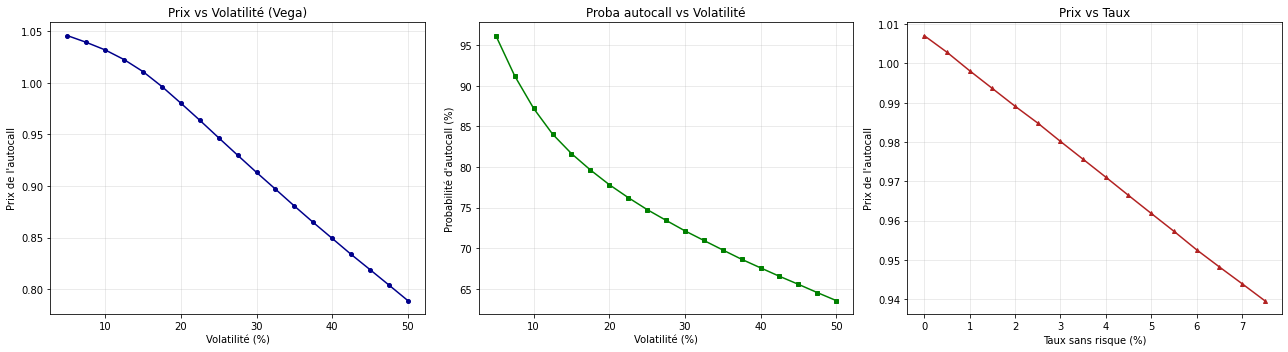

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(vols_test * 100, prix_par_vol, 'o-', color='darkblue', ms=4)
axes[0].set_xlabel('Volatilité (%)')
axes[0].set_ylabel("Prix de l'autocall")
axes[0].set_title('Prix vs Volatilité (Vega)')

axes[1].plot(vols_test * 100, np.array(proba_ac_par_vol) * 100, 's-', color='green', ms=4)
axes[1].set_xlabel('Volatilité (%)')
axes[1].set_ylabel("Probabilité d'autocall (%)")
axes[1].set_title("Proba autocall vs Volatilité")

axes[2].plot(taux_test * 100, prix_par_taux, '^-', color='firebrick', ms=4)
axes[2].set_xlabel('Taux sans risque (%)')
axes[2].set_ylabel("Prix de l'autocall")
axes[2].set_title('Prix vs Taux')

plt.tight_layout()
plt.show()

## 5bis. Calcul des grecs : delta, gamma, vega

On calcule les grecs par différences finies (bump & reprice) :

$$\Delta = \frac{V(S+dS) - V(S-dS)}{2\,dS} \qquad
\Gamma = \frac{V(S+dS) - 2V(S) + V(S-dS)}{dS^2} \qquad
\mathcal{V} = \frac{V(\sigma+d\sigma) - V(\sigma-d\sigma)}{2\,d\sigma}$$

On les évalue pour différents niveaux de spot et de volatilité, à $t=0$.

In [8]:
# Pour les grecs on n'a besoin du spot qu'aux dates d'observation (5 dates)
# => on simule directement S aux dates t=1,2,3,4,5 sans pas journalier
# Beaucoup plus léger en mémoire et en temps

nb_sim_grecs = 20_000
np.random.seed(77)

# aléas pour chaque intervalle entre observations
# Z_k ~ N(0,1) pour l'intervalle [t_{k-1}, t_k] de durée 1 an
aleas_obs = np.random.standard_normal((nb_sim_grecs, len(dates_obs)))

def pricer_grecs(s0_test, r, sigma, dates_obs, bar_ac, coupon, bar_cap, aleas):
    """Pricer simplifié pour grecs : simule le spot uniquement aux dates d'obs."""
    nb_sim = aleas.shape[0]
    dt_obs = 1.0  # intervalle entre observations
    
    # construction des spots aux dates d'observation
    spots_aux_obs = np.zeros((nb_sim, len(dates_obs)))
    s_prev = np.full(nb_sim, s0_test)
    for k in range(len(dates_obs)):
        s_prev = s_prev * np.exp((r - 0.5*sigma**2)*dt_obs + sigma*np.sqrt(dt_obs)*aleas[:, k])
        spots_aux_obs[:, k] = s_prev
    
    # pricing
    payoffs = np.zeros(nb_sim)
    vivantes = np.ones(nb_sim, dtype=bool)
    
    for k, t_obs in enumerate(dates_obs):
        spots = spots_aux_obs[vivantes, k]
        ac = spots >= bar_ac * spot_0
        idx_viv = np.where(vivantes)[0]
        idx_ac = idx_viv[ac]
        payoffs[idx_ac] = (1.0 + coupon * t_obs) * np.exp(-r * t_obs)
        vivantes[idx_ac] = False
    
    if vivantes.any():
        idx_viv = np.where(vivantes)[0]
        s_fin = spots_aux_obs[idx_viv, -1]
        disc = np.exp(-r * dates_obs[-1])
        prot = s_fin >= bar_cap * spot_0
        payoffs[idx_viv[prot]] = disc
        payoffs[idx_viv[~prot]] = (s_fin[~prot] / spot_0) * disc
    
    return payoffs.mean()

# --- Delta et Gamma en fonction du spot ---
spots_grec = np.linspace(50, 180, 20)
deltas = []
gammas = []

for s in spots_grec:
    ds = s * 0.01
    p_up = pricer_grecs(s + ds, taux, vol, dates_obs, barriere_autocall, coupon_annuel, barriere_capital, aleas_obs)
    p_mid = pricer_grecs(s, taux, vol, dates_obs, barriere_autocall, coupon_annuel, barriere_capital, aleas_obs)
    p_down = pricer_grecs(s - ds, taux, vol, dates_obs, barriere_autocall, coupon_annuel, barriere_capital, aleas_obs)
    deltas.append((p_up - p_down) / (2 * ds) * spot_0)
    gammas.append((p_up - 2*p_mid + p_down) / (ds**2) * spot_0**2)

# --- Vega en fonction de la vol ---
vols_vega = np.arange(0.10, 0.42, 0.04)
vegas = []

for v in vols_vega:
    dv = 0.01
    p_up = pricer_grecs(spot_0, taux, v + dv, dates_obs, barriere_autocall, coupon_annuel, barriere_capital, aleas_obs)
    p_down = pricer_grecs(spot_0, taux, v - dv, dates_obs, barriere_autocall, coupon_annuel, barriere_capital, aleas_obs)
    vegas.append((p_up - p_down) / (2 * dv))

print("Grecs calculés.")

Grecs calculés.


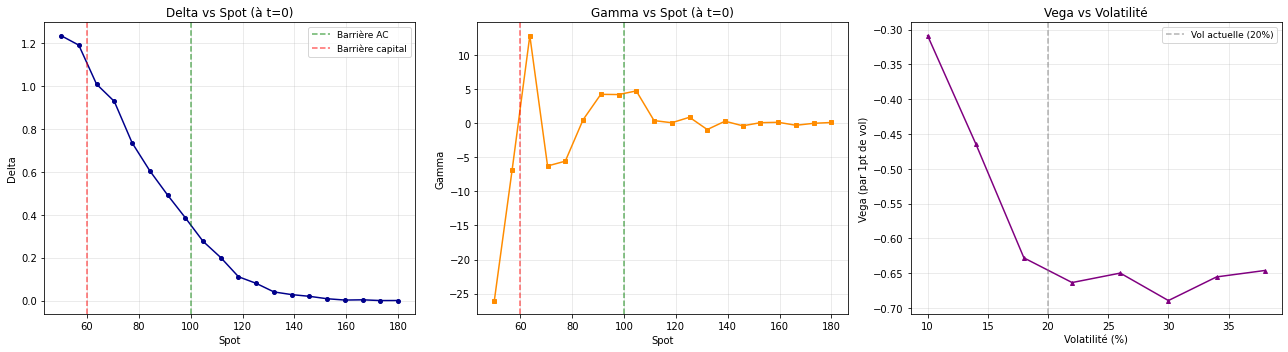

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(spots_grec, deltas, 'o-', color='darkblue', ms=4)
ax.axvline(barriere_autocall * spot_0, color='green', ls='--', alpha=0.6, label='Barrière AC')
ax.axvline(barriere_capital * spot_0, color='red', ls='--', alpha=0.6, label='Barrière capital')
ax.set_xlabel('Spot')
ax.set_ylabel('Delta')
ax.set_title('Delta vs Spot (à t=0)')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(spots_grec, gammas, 's-', color='darkorange', ms=4)
ax.axvline(barriere_autocall * spot_0, color='green', ls='--', alpha=0.6)
ax.axvline(barriere_capital * spot_0, color='red', ls='--', alpha=0.6)
ax.set_xlabel('Spot')
ax.set_ylabel('Gamma')
ax.set_title('Gamma vs Spot (à t=0)')

ax = axes[2]
ax.plot(vols_vega * 100, vegas, '^-', color='purple', ms=4)
ax.axvline(vol * 100, color='grey', ls='--', alpha=0.6, label=f'Vol actuelle ({vol*100:.0f}%)')
ax.set_xlabel('Volatilité (%)')
ax.set_ylabel('Vega (par 1pt de vol)')
ax.set_title('Vega vs Volatilité')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Taux stochastiques — Modèle de Vasicek

On introduit un modèle de taux court pour l'actualisation :

$$dr_t = a(b - r_t) \, dt + \sigma_r \, dW_t^r$$

Les browniens du spot et du taux sont corrélés ($\rho = -0.2$, corrélation négative classique).
L'actualisation devient stochastique : $D(0,T) = \exp\left(-\int_0^T r_t \, dt\right)$.

On compare le prix obtenu avec celui sous taux constant, et on étudie
l'impact des paramètres Vasicek ($\sigma_r$, $\rho$).

In [10]:
a_vasicek = 0.5
b_vasicek = 0.03
sigma_r = 0.01
rho_sr = -0.2

def simuler_bs_vasicek(s0, r0, sigma_s, a, b, sig_r, rho, T, nb_pas, nb_sim):
    """Simulation conjointe GBM + Vasicek."""
    dt = T / nb_pas
    sqrt_dt = np.sqrt(dt)
    z1 = np.random.standard_normal((nb_sim, nb_pas))
    z2 = rho * z1 + np.sqrt(1 - rho**2) * np.random.standard_normal((nb_sim, nb_pas))
    
    traj_r = np.zeros((nb_sim, nb_pas + 1))
    traj_r[:, 0] = r0
    for j in range(nb_pas):
        traj_r[:, j+1] = traj_r[:, j] + a * (b - traj_r[:, j]) * dt + sig_r * sqrt_dt * z2[:, j]
    
    log_inc = (traj_r[:, :-1] - 0.5 * sigma_s**2) * dt + sigma_s * sqrt_dt * z1
    log_spots = np.concatenate([np.zeros((nb_sim, 1)), np.cumsum(log_inc, axis=1)], axis=1)
    traj_s = s0 * np.exp(log_spots)
    return traj_s, traj_r

def pricer_autocall_taux_stoch(traj_s, traj_r, s0, dates_obs, barriere_ac, coupon, barriere_cap, nb_pas_an):
    """Pricer autocall avec actualisation stochastique."""
    nb_sim = traj_s.shape[0]
    nb_pas = traj_s.shape[1] - 1
    dt = (nb_pas / nb_pas_an) / nb_pas
    
    payoffs = np.zeros(nb_sim)
    dates_autocall = np.full(nb_sim, np.nan)
    vivantes = np.ones(nb_sim, dtype=bool)
    cum_r = np.cumsum(traj_r[:, :-1] * dt, axis=1)
    
    for t_obs in dates_obs:
        idx = min(int(t_obs * nb_pas_an), nb_pas - 1)
        spots = traj_s[vivantes, idx]
        ac_mask = spots >= barriere_ac * s0
        idx_viv = np.where(vivantes)[0]
        idx_ac = idx_viv[ac_mask]
        
        payoffs[idx_ac] = (1.0 + coupon * t_obs) * np.exp(-cum_r[idx_ac, idx - 1])
        dates_autocall[idx_ac] = t_obs
        vivantes[idx_ac] = False
    
    if vivantes.any():
        idx_viv = np.where(vivantes)[0]
        s_fin = traj_s[idx_viv, -1]
        disc = np.exp(-cum_r[idx_viv, -1])
        protege = s_fin >= barriere_cap * s0
        payoffs[idx_viv[protege]] = 1.0 * disc[protege]
        payoffs[idx_viv[~protege]] = (s_fin[~protege] / s0) * disc[~protege]
    
    return payoffs.mean(), payoffs, dates_autocall

In [11]:
np.random.seed(42)
traj_s_v, traj_r_v = simuler_bs_vasicek(
    spot_0, taux, vol, a_vasicek, b_vasicek, sigma_r, rho_sr,
    maturite, nb_pas_par_an * maturite, nb_simus
)

prix_stoch, payoffs_stoch, dates_stoch = pricer_autocall_taux_stoch(
    traj_s_v, traj_r_v, spot_0, dates_obs,
    barriere_autocall, coupon_annuel, barriere_capital, nb_pas_par_an
)

print(f"Prix (taux constant)     : {prix_autocall:.4f}")
print(f"Prix (taux Vasicek)      : {prix_stoch:.4f}")
print(f"Écart                    : {(prix_stoch - prix_autocall)*10000:.1f} bps")

# probas d'autocall sous les deux modèles
proba_ac_cst = autocalled_mask.mean()
proba_ac_stoch = (~np.isnan(dates_stoch)).mean()

print(f"\nProba autocall (taux cst)   : {proba_ac_cst*100:.1f}%")
print(f"Proba autocall (Vasicek)    : {proba_ac_stoch*100:.1f}%")

Prix (taux constant)     : 0.9807
Prix (taux Vasicek)      : 0.9811
Écart                    : 4.6 bps

Proba autocall (taux cst)   : 77.9%
Proba autocall (Vasicek)    : 78.0%


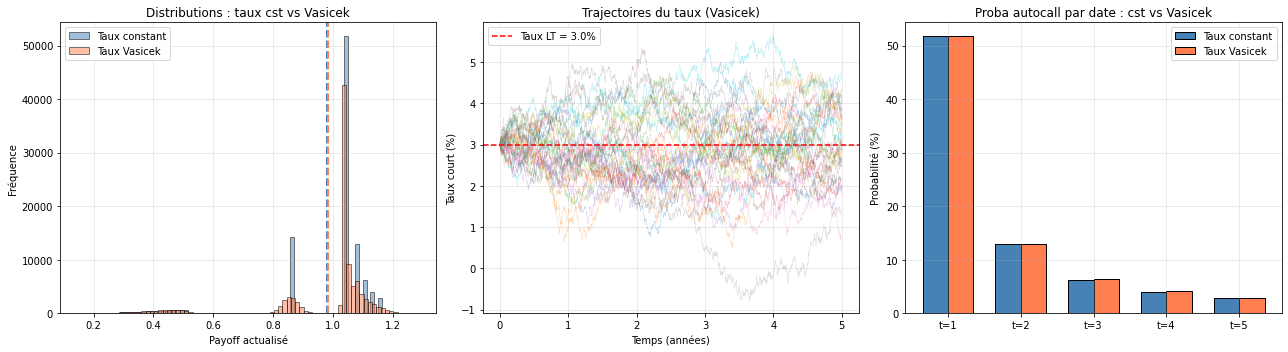

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# distributions comparées
axes[0].hist(payoffs_ac, bins=80, alpha=0.5, label='Taux constant', color='steelblue', edgecolor='black')
axes[0].hist(payoffs_stoch, bins=80, alpha=0.5, label='Taux Vasicek', color='coral', edgecolor='black')
axes[0].axvline(prix_autocall, color='steelblue', lw=2, ls='--')
axes[0].axvline(prix_stoch, color='coral', lw=2, ls='--')
axes[0].set_xlabel('Payoff actualisé')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distributions : taux cst vs Vasicek')
axes[0].legend()

# trajectoires du taux
t_grid_r = np.linspace(0, maturite, nb_pas_par_an * maturite + 1)
for k in range(30):
    axes[1].plot(t_grid_r, traj_r_v[k] * 100, alpha=0.3, linewidth=0.5)
axes[1].axhline(b_vasicek * 100, color='red', ls='--', label=f'Taux LT = {b_vasicek*100}%')
axes[1].set_xlabel('Temps (années)')
axes[1].set_ylabel('Taux court (%)')
axes[1].set_title('Trajectoires du taux (Vasicek)')
axes[1].legend()

# proba autocall par date : comparaison
probas_cst = [(dates_ac == t).mean() * 100 for t in dates_obs]
probas_stoch = [(dates_stoch == t).mean() * 100 for t in dates_obs]
x = np.arange(len(dates_obs))
w = 0.35
axes[2].bar(x - w/2, probas_cst, w, label='Taux constant', color='steelblue', edgecolor='black')
axes[2].bar(x + w/2, probas_stoch, w, label='Taux Vasicek', color='coral', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f't={int(t)}' for t in dates_obs])
axes[2].set_ylabel('Probabilité (%)')
axes[2].set_title('Proba autocall par date : cst vs Vasicek')
axes[2].legend()

plt.tight_layout()
plt.show()

### Sensibilité aux paramètres Vasicek

On fait varier $\sigma_r$ (volatilité du taux) et $\rho$ (corrélation spot/taux)
pour mesurer leur impact sur le prix.

In [13]:
# impact de sigma_r
sigmas_r_test = [0.005, 0.01, 0.02, 0.03, 0.05]
prix_par_sigma_r = []

for sr in sigmas_r_test:
    np.random.seed(42)
    ts, tr = simuler_bs_vasicek(spot_0, taux, vol, a_vasicek, b_vasicek, sr, rho_sr,
                                 maturite, nb_pas_par_an * maturite, 30_000)
    p, _, _ = pricer_autocall_taux_stoch(ts, tr, spot_0, dates_obs,
                                          barriere_autocall, coupon_annuel, barriere_capital, nb_pas_par_an)
    prix_par_sigma_r.append(p)
    print(f"  sigma_r={sr:.3f}  =>  prix={p:.4f}  écart={((p - prix_autocall)*10000):.1f} bps")

# impact de rho
rhos_test = [-0.5, -0.3, -0.2, 0.0, 0.2, 0.3, 0.5]
prix_par_rho = []

for rh in rhos_test:
    np.random.seed(42)
    ts, tr = simuler_bs_vasicek(spot_0, taux, vol, a_vasicek, b_vasicek, sigma_r, rh,
                                 maturite, nb_pas_par_an * maturite, 30_000)
    p, _, _ = pricer_autocall_taux_stoch(ts, tr, spot_0, dates_obs,
                                          barriere_autocall, coupon_annuel, barriere_capital, nb_pas_par_an)
    prix_par_rho.append(p)
    print(f"  rho={rh:+.1f}  =>  prix={p:.4f}")

  sigma_r=0.005  =>  prix=0.9813  écart=6.4 bps
  sigma_r=0.010  =>  prix=0.9815  écart=7.8 bps
  sigma_r=0.020  =>  prix=0.9818  écart=11.1 bps
  sigma_r=0.030  =>  prix=0.9819  écart=12.4 bps
  sigma_r=0.050  =>  prix=0.9826  écart=19.2 bps
  rho=-0.5  =>  prix=0.9821
  rho=-0.3  =>  prix=0.9816
  rho=-0.2  =>  prix=0.9815
  rho=+0.0  =>  prix=0.9810
  rho=+0.2  =>  prix=0.9803
  rho=+0.3  =>  prix=0.9801
  rho=+0.5  =>  prix=0.9796


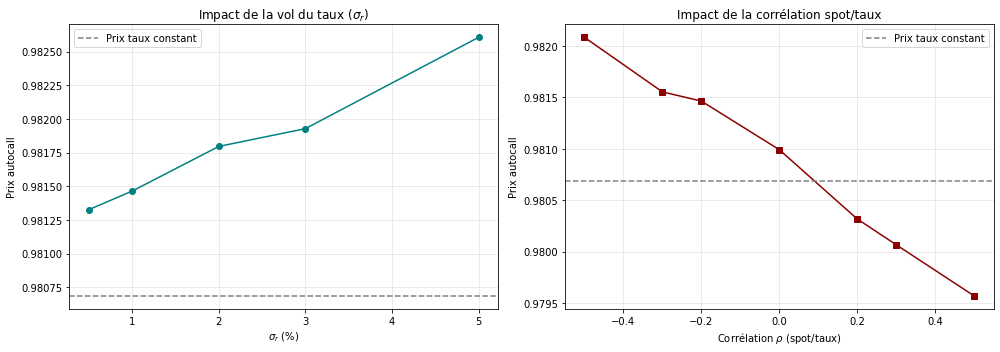

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([s*100 for s in sigmas_r_test], prix_par_sigma_r, 'o-', color='teal', ms=6)
axes[0].axhline(prix_autocall, color='grey', ls='--', label='Prix taux constant')
axes[0].set_xlabel('$\\sigma_r$ (%)')
axes[0].set_ylabel('Prix autocall')
axes[0].set_title('Impact de la vol du taux ($\\sigma_r$)')
axes[0].legend()

axes[1].plot(rhos_test, prix_par_rho, 's-', color='darkred', ms=6)
axes[1].axhline(prix_autocall, color='grey', ls='--', label='Prix taux constant')
axes[1].set_xlabel('Corrélation $\\rho$ (spot/taux)')
axes[1].set_ylabel('Prix autocall')
axes[1].set_title('Impact de la corrélation spot/taux')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Delta hedging

Le delta est estimé par bump & reprice :
$$\Delta = \frac{V(S + dS) - V(S - dS)}{2 \, dS}$$

**Optimisation** : plutôt que de recalculer le delta à chaque pas (très coûteux),
on pré-calcule une grille de deltas sur un maillage $(S, t)$, puis on interpole
pendant la simulation du hedging. On ne calcule la grille qu'une seule fois.

In [15]:
def construire_grille_delta(s0, r, sigma, dates_obs, barriere_ac, coupon,
                             barriere_cap, nb_sim_mc=10_000,
                             spots_grid=None, temps_grid=None):
    """
    Pré-calcule le delta sur une grille (spot, temps).
    On simule le spot uniquement aux dates d'observation restantes
    (pas de trajectoire journalière) pour aller beaucoup plus vite.
    """
    if spots_grid is None:
        spots_grid = np.linspace(40, 200, 25)
    if temps_grid is None:
        temps_grid = np.linspace(0, dates_obs[-1] - 0.01, 40)
    
    delta_grid = np.zeros((len(temps_grid), len(spots_grid)))
    
    for i, t in enumerate(temps_grid):
        dates_restantes = dates_obs[dates_obs > t + 1e-6]
        if len(dates_restantes) == 0:
            continue
        
        n_obs = len(dates_restantes)
        # durées entre les observations restantes
        temps_debut = max(t, 0)
        dt_obs = np.diff(np.concatenate([[temps_debut], dates_restantes]))
        
        # aléas communs pour tous les spots de cette ligne de temps
        np.random.seed(i * 1000)
        aleas = np.random.standard_normal((nb_sim_mc, n_obs))
        
        for j, s in enumerate(spots_grid):
            ds = s * 0.01
            
            # simuler les spots aux dates d'obs pour s+ds et s-ds
            for s_test, label in [(s + ds, 'up'), (s - ds, 'down')]:
                spots_obs = np.zeros((nb_sim_mc, n_obs))
                s_prev = np.full(nb_sim_mc, s_test)
                for k in range(n_obs):
                    s_prev = s_prev * np.exp((r - 0.5*sigma**2)*dt_obs[k] + sigma*np.sqrt(dt_obs[k])*aleas[:, k])
                    spots_obs[:, k] = s_prev
                
                # pricer inline (vectorisé sur les obs restantes)
                payoffs = np.zeros(nb_sim_mc)
                vivantes = np.ones(nb_sim_mc, dtype=bool)
                for k, t_obs in enumerate(dates_restantes):
                    sp = spots_obs[vivantes, k]
                    ac = sp >= barriere_ac * s0
                    iv = np.where(vivantes)[0]
                    ia = iv[ac]
                    payoffs[ia] = (1.0 + coupon * t_obs) * np.exp(-r * t_obs)
                    vivantes[ia] = False
                
                if vivantes.any():
                    iv = np.where(vivantes)[0]
                    sf = spots_obs[iv, -1]
                    disc = np.exp(-r * dates_restantes[-1])
                    prot = sf >= barriere_cap * s0
                    payoffs[iv[prot]] = disc
                    payoffs[iv[~prot]] = (sf[~prot] / s0) * disc
                
                if label == 'up':
                    p_up = payoffs.mean()
                else:
                    p_down = payoffs.mean()
            
            delta_grid[i, j] = (p_up - p_down) / (2 * ds) * s0
    
    interpolateur = RegularGridInterpolator(
        (temps_grid, spots_grid), delta_grid,
        method='linear', bounds_error=False, fill_value=0.0
    )
    return delta_grid, temps_grid, spots_grid, interpolateur

In [16]:
print("Construction de la grille de deltas...")
t0 = time.time()

delta_grid, temps_grid, spots_grid, interp_delta = construire_grille_delta(
    spot_0, taux, vol, dates_obs,
    barriere_autocall, coupon_annuel, barriere_capital,
    nb_sim_mc=10_000,
    spots_grid=np.linspace(40, 200, 25),
    temps_grid=np.linspace(0, maturite - 0.01, 40)
)

print(f"Grille calculée en {time.time()-t0:.1f}s")
print(f"Taille : {delta_grid.shape[0]} temps x {delta_grid.shape[1]} spots")

Construction de la grille de deltas...
Grille calculée en 2.5s
Taille : 40 temps x 25 spots


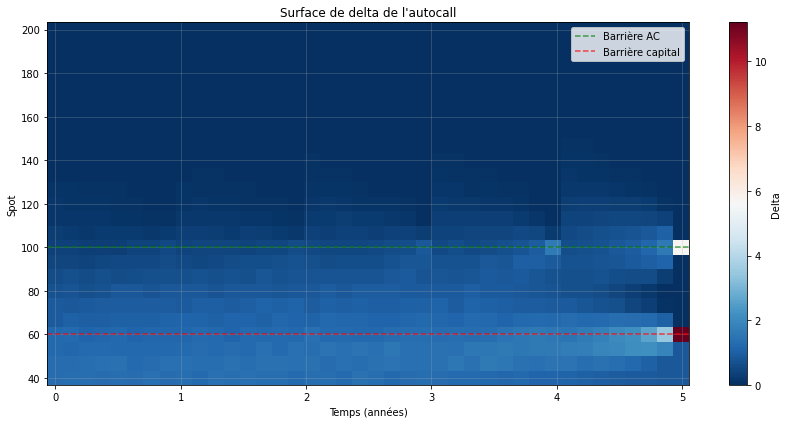

In [17]:
# visualisation de la surface de delta
fig, ax = plt.subplots(figsize=(12, 6))
T_mesh, S_mesh = np.meshgrid(temps_grid, spots_grid, indexing='ij')
c = ax.pcolormesh(T_mesh, S_mesh, delta_grid, shading='auto', cmap='RdBu_r')
ax.set_xlabel('Temps (années)')
ax.set_ylabel('Spot')
ax.set_title('Surface de delta de l\'autocall')
ax.axhline(barriere_autocall * spot_0, color='green', ls='--', alpha=0.7, label='Barrière AC')
ax.axhline(barriere_capital * spot_0, color='red', ls='--', alpha=0.7, label='Barrière capital')
ax.legend()
plt.colorbar(c, label='Delta')
plt.tight_layout()
plt.show()

In [18]:
def simuler_delta_hedging(trajectoire, s0, r, interp, dates_obs, barriere_ac,
                           coupon, barriere_cap, prix_init, freq_rebal=5):
    """
    Simule le delta hedging en utilisant l'interpolateur pré-calculé.
    Beaucoup plus rapide car pas de Monte Carlo à chaque pas.
    """
    nb_pas = len(trajectoire) - 1
    dt = 1 / 252
    
    cash = prix_init * s0
    position_spot = 0.0
    idx_obs = {int(t * 252): t for t in dates_obs}
    
    for j in range(nb_pas):
        t_courant = j * dt
        spot_j = trajectoire[j]
        
        # autocall ?
        if j in idx_obs:
            t_obs = idx_obs[j]
            if spot_j >= barriere_ac * s0:
                payoff = (1.0 + coupon * t_obs) * s0
                cash += position_spot * spot_j
                return cash - payoff
        
        # rebalancement
        if j % freq_rebal == 0:
            delta_new = float(interp(np.array([[t_courant, spot_j]])))
            cash -= (delta_new - position_spot) * spot_j
            position_spot = delta_new
        
        cash *= np.exp(r * dt)
    
    # maturité
    spot_final = trajectoire[-1]
    cash += position_spot * spot_final
    payoff = s0 if spot_final >= barriere_cap * s0 else spot_final
    return cash - payoff

In [19]:
# --- Hedging principal ---
print("Simulation du delta hedging (avec grille interpolée)...")
t0 = time.time()

nb_hedge_simus = 500   # on peut se permettre beaucoup plus maintenant
pnl_hedging = np.zeros(nb_hedge_simus)

for k in range(nb_hedge_simus):
    if k % 100 == 0:
        print(f"  {k}/{nb_hedge_simus}...")
    pnl_hedging[k] = simuler_delta_hedging(
        trajectoires[k], spot_0, taux, interp_delta, dates_obs,
        barriere_autocall, coupon_annuel, barriere_capital,
        prix_init=prix_autocall, freq_rebal=5
    )

print(f"\nTerminé en {time.time()-t0:.1f}s")
print(f"PnL moyen   : {pnl_hedging.mean():.2f}")
print(f"PnL std     : {pnl_hedging.std():.2f}")
print(f"PnL min/max : [{pnl_hedging.min():.2f}, {pnl_hedging.max():.2f}]")

Simulation du delta hedging (avec grille interpolée)...
  0/500...
  100/500...
  200/500...
  300/500...
  400/500...

Terminé en 6.0s
PnL moyen   : 0.51
PnL std     : 5.87
PnL min/max : [-23.86, 45.72]


## 8. Impact de la fréquence de rebalancement et de la volatilité réalisée

In [20]:
# --- Fréquence de rebalancement ---
print("Impact de la fréquence de rebalancement...")
freqs_test = [1, 5, 10, 20]
pnl_par_freq = {}
nb_test = 300

for freq in freqs_test:
    pnls = np.zeros(nb_test)
    for k in range(nb_test):
        pnls[k] = simuler_delta_hedging(
            trajectoires[k], spot_0, taux, interp_delta, dates_obs,
            barriere_autocall, coupon_annuel, barriere_capital,
            prix_init=prix_autocall, freq_rebal=freq
        )
    pnl_par_freq[freq] = pnls
    print(f"  freq={freq:2d}j  mean={pnls.mean():+.2f}  std={pnls.std():.2f}")

Impact de la fréquence de rebalancement...
  freq= 1j  mean=+0.23  std=5.83
  freq= 5j  mean=+0.39  std=5.96
  freq=10j  mean=+0.36  std=6.10
  freq=20j  mean=+0.19  std=5.89


In [21]:
# --- Vol réalisée vs vol de modèle ---
# on hedge avec vol=20% mais le marché réalise une vol différente
# il faut recalculer la grille de delta pour chaque vol ? Non :
# le hedger utilise toujours la même grille (vol modèle = 20%),
# mais les trajectoires sont simulées avec la vol réalisée.

print("Impact de la vol réalisée...")
vols_realisees = [0.15, 0.20, 0.25, 0.30]
pnl_par_vol_hedge = {}

for vol_real in vols_realisees:
    pnls = np.zeros(nb_test)
    for k in range(nb_test):
        np.random.seed(2000 + k)
        traj_h = simuler_trajectoires_bs(spot_0, taux, vol_real, maturite, 252 * maturite, 1)
        pnls[k] = simuler_delta_hedging(
            traj_h[0], spot_0, taux, interp_delta, dates_obs,
            barriere_autocall, coupon_annuel, barriere_capital,
            prix_init=prix_autocall, freq_rebal=5
        )
    pnl_par_vol_hedge[vol_real] = pnls
    print(f"  vol_réalisée={vol_real*100:.0f}%  mean={pnls.mean():+.2f}  std={pnls.std():.2f}")

Impact de la vol réalisée...
  vol_réalisée=15%  mean=-2.15  std=5.98
  vol_réalisée=20%  mean=+1.61  std=7.07
  vol_réalisée=25%  mean=+4.69  std=8.01
  vol_réalisée=30%  mean=+7.88  std=10.15


## 9. Graphiques de synthèse — Hedging

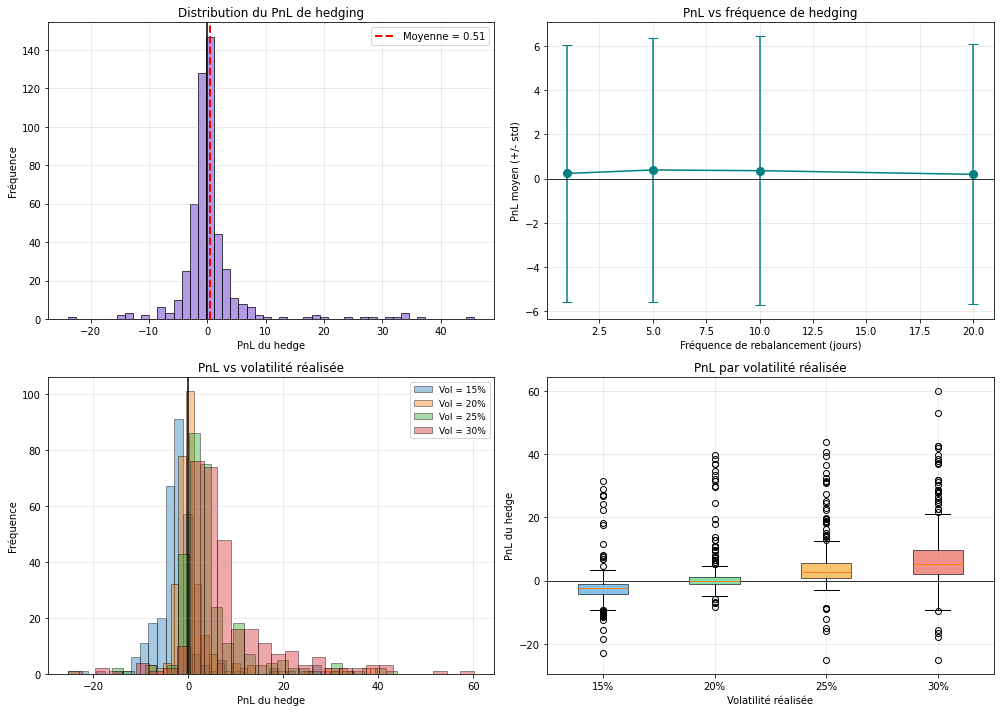

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.hist(pnl_hedging, bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
ax.axvline(0, color='black', lw=1.5)
ax.axvline(pnl_hedging.mean(), color='red', lw=2, ls='--', label=f'Moyenne = {pnl_hedging.mean():.2f}')
ax.set_xlabel('PnL du hedge')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du PnL de hedging')
ax.legend()

ax = axes[0, 1]
means = [pnl_par_freq[f].mean() for f in freqs_test]
stds = [pnl_par_freq[f].std() for f in freqs_test]
ax.errorbar(freqs_test, means, yerr=stds, fmt='o-', capsize=5, color='teal', ms=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Fréquence de rebalancement (jours)')
ax.set_ylabel('PnL moyen (+/- std)')
ax.set_title('PnL vs fréquence de hedging')

ax = axes[1, 0]
for vol_r in vols_realisees:
    ax.hist(pnl_par_vol_hedge[vol_r], bins=30, alpha=0.4, label=f'Vol = {vol_r*100:.0f}%', edgecolor='black')
ax.axvline(0, color='black', lw=1.5)
ax.set_xlabel('PnL du hedge')
ax.set_ylabel('Fréquence')
ax.set_title('PnL vs volatilité réalisée')
ax.legend(fontsize=9)

ax = axes[1, 1]
bp = ax.boxplot([pnl_par_vol_hedge[v] for v in vols_realisees],
                labels=[f'{v*100:.0f}%' for v in vols_realisees], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Volatilité réalisée')
ax.set_ylabel('PnL du hedge')
ax.set_title('PnL par volatilité réalisée')

plt.tight_layout()
plt.show()

## 11. Conclusions

**Pricing :**

- La **volatilité** a un impact majeur : plus elle est haute, plus la probabilité d'autocall diminue, ce qui réduit le prix du produit.

- Le **taux** joue via le drift risque-neutre (favorise l'autocall si haut) et l'actualisation (réduit la valeur présente).

- Les **taux stochastiques** (Vasicek) modifient le prix via l'incertitude sur l'actualisation. L'impact dépend de $\sigma_r$ et de la corrélation $\rho$ : une corrélation négative (cas classique) fait que lorsque le spot baisse, les taux montent, ce qui diminue la valeur des coupons futurs.

**Grecs :**

- Le **delta** est fortement non-linéaire autour de la barrière autocall : il y a une discontinuité due au saut de payoff à la barrière.

- Le **gamma** est concentré autour des barrières, ce qui rend le produit difficile à hedger dans ces zones (coût de rebalancement élevé).

- Le **vega** est négatif : le vendeur de l'autocall est short vega, car une hausse de la vol réduit la proba d'autocall et donc la valeur du produit.

**Hedging :**

- Le delta hedging laisse un PnL résiduel lié au **gamma** (convexité non couverte).

- Plus la **fréquence de rebalancement** est élevée, plus la variance du PnL diminue, au prix de coûts de transaction plus élevés.

- Le **mismatch vol modèle / vol réalisée** est une source majeure de PnL de hedging (risque vega).